# Previsão de Pacientes com Diabetes

Irei usar um dataset que tem as informações de pacientes com diabetes, basicamente, o objetivo vai ser prever se um paciente tem ou não diabetes, então, é um problema de classificação binária, onde o resultado pode ser com 0 ou 1, onde 0 é para pacientes sem daiabetes e 1 para pacientes com diabetes.  
O dataset foi baixado do Kaggle, link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database.

Irei iniciar importando as bibliotecas necessárias para o desenvolvimento do projeto, como o pandas para manipulação de dados, o tensorflow para construção do modelo de rede neural, o sklearn para pré-processamento dos dados e avaliação do modelo, e o matplotlib para visualização dos resultados.

In [14]:
# imports
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

Agora, vou iniciar analisando o dataser, para isso, vou carregar o dataset usando o pandas e olhar as primeiras linhas para ver a estrutura dos dados, também analisar o formato do dataset, ver se tem dados faltantes.

In [ ]:
X = pd.read_csv('diabetes_pratica.csv', sep=',')
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


As colunas do dataset são: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age e Outcome. Cada coluna se refere a uma característica dos pacientes, sendo elas:  
- **Pregnancies:** número de gestações
- **Glucose:** concentração de glicose no sangue
- **BloodPressure:** pressão arterial
- **SkinThickness:** espessura da pele
- **Insulin:** nível de insulina
- **BMI:** índice de massa corporal
- **DiabetesPedigreeFunction:** função de pedigree de diabetes
- **Age:** idade
- **Outcome:** resultado da previsão (0 ou 1)

A coluna Outcome é a variável que quero prever, ou seja, se o paciente tem ou não tem diabetes, logo, vou separar essa coluna do resto. Vou primeiro verificar se há dados faltantes e o formato do dataset.

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Como o .info() já mostra se tem dados nulos e o formato do dataset, não preciso usar o .isnull() e o .shape() como na aula.  
Agora, vou separa a coluna Outcome do resto e para isso, vou usar o .drop() para tirar a coluna e criar um nvo dataframe chamado y com a coluna Outcome.

In [23]:
y = X['Outcome']
X = X.drop('Outcome', axis = 1)
X, y

(     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0              6      148             72             35        0  33.6   
 1              1       85             66             29        0  26.6   
 2              8      183             64              0        0  23.3   
 3              1       89             66             23       94  28.1   
 4              0      137             40             35      168  43.1   
 ..           ...      ...            ...            ...      ...   ...   
 763           10      101             76             48      180  32.9   
 764            2      122             70             27        0  36.8   
 765            5      121             72             23      112  26.2   
 766            1      126             60              0        0  30.1   
 767            1       93             70             31        0  30.4   
 
      DiabetesPedigreeFunction  Age  
 0                       0.627   50  
 1                    

Feito isso, agora tenho os dados para treinamento prontos, não precisei transformar nenhum dado categórico em numérico, pois todas as colunas já são numéricas, então, vou seguir para a próxima etapa: fazer a divisão dos dados em treino e teste, para isso, vou usar o train_test_split do sklearn, e vou separar 20% dos dados para teste e 80% para treino, também vou usar o K-Fold para fazer a validação cruzada, e vou usar o KFold do sklearn para isso, vou usar 10 folds para a validação cruzada.

In [26]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((614, 8), (154, 8), (614,), (154,))

Como pode ver, após a divisão dos dados, ficaram 614 amostras para treino e 154 para teste.  
Agora vou iniciar a construção do modelo de rede neural, vou usar o cálculo de número de colunas + 1 e dividir o resultado por 2 para definir o número de neurônios na camada oculta, também vou usar a função de ativação ReLU para as camadas ocultas e a função de ativação sigmoid para a camada de saída, já que é um problema de classificação binária.  
Rede neural pronta, agora vou compilar o modelo usando a função de perda binary_crossentropy, o otimizador Adam e a métrica de acurácia.  
A taxa de aprendizado está em 0.001 porque é o valor padrão do otimizador Adam, e é um valor que geralmente funciona bem para a maioria dos problemas de classificação binária.  
Agora vou compilar a rede neural usando o otimizador Adam, com a função de perda binary_crossentropy e a métrica de acurácia binária para avaliar o desempenho do modelo durante o treinamento.

In [27]:
(8 + 1) / 2

4.5

In [32]:
def criar_rede_neural():
    rede_neural = Sequential([
        tf.keras.layers.InputLayer(shape = (8,)),
        tf.keras.layers.Dense(units = 5, activation = 'relu', kernel_initializer = 'random_uniform'),
        tf.keras.layers.Dense(units = 5, activation = 'relu', kernel_initializer = 'random_uniform'),
        tf.keras.layers.Dense(units = 1, activation = 'sigmoid')
    ])
    otimizador = tf.keras.optimizers.Adam(learning_rate = 0.001, clipvalue = 0.5)
    rede_neural.compile(optimizer = otimizador, loss = 'binary_crossentropy', metrics = ['binary_accuracy'])
    return rede_neural

In [35]:
rede_neural = KerasClassifier(model = criar_rede_neural, epochs = 100, batch_size = 10)

In [37]:
resultados = cross_val_score(rede_neural, X_treino, y_treino, cv = 10)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.6377 - loss: 0.6584
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6594 - loss: 0.6474
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6522 - loss: 0.6389
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6739 - loss: 0.6304
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6685 - loss: 0.6261
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6757 - loss: 0.6222
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6830 - loss: 0.6102
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6902 - loss: 0.6107
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6649 - loss: 0.6089
Epoch 10/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6775 - loss: 0.6032
Epoch 11/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6957 -

Agora, vamos ver os resultados da validação cruzada, vou calcular também a média e o desvio padrão dos resultados para ter uma ideia melhor do desempenho do modelo.

In [39]:
resultados

array([0.77419355, 0.82258065, 0.62903226, 0.61290323, 0.60655738,
       0.6557377 , 0.73770492, 0.7704918 , 0.75409836, 0.68852459])

In [40]:
print(f"Média dos resultados: {resultados.mean()}\nDesvio padrão dos resultados: {resultados.std()}")

Média dos resultados: 0.7051824431517716
Desvio padrão dos resultados: 0.07281767358979084


Observe que a média é aproximadamente 0.705 e o desvio padrão, que indica o quanto os resultados variam em relação a média, é aproximadamente 0.072, o que indica que os resultados estão até próximos da média, então, o modelo tem um desempenho até razoável, mas ainda daria para melhorar.

In [41]:
rede_neural.fit(X_treino, y_treino)
previsoes = rede_neural.predict(X_teste)
previsoes

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.6515 - loss: 0.6671
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6547 - loss: 0.6477
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6580 - loss: 0.6324
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6678 - loss: 0.6256
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6759 - loss: 0.6094
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6759 - loss: 0.6146
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6792 - loss: 0.5956
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6889 - loss: 0.5992
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6873 - loss: 0.5932
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.6889 - loss: 0.5975
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6824 -

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

In [44]:
previsoes = previsoes > 0.5

In [46]:
accuracy_score(y_teste, previsoes)

0.7792207792207793

In [47]:
confusion_matrix(y_teste, previsoes)

array([[89, 10],
       [24, 31]], dtype=int64)

Usando o accuracy_score do sklearn, o modelo teve uma acurácia de aproximadamente 0.779, um desempenho razoável, já a matriz de confusão mostrou que o modelo teve 89 verdadeiros positivos, 10 falsos positivos, 24 falsos negativos e 31 verdadeiros negativos, isso mostra que ele acertou 89 casos de pacientes com diabetes e 31 casos de pacientes sem diabetes, mas errou 10 casos de pacientes sem diabetes e 24 casos de pacientes com diabetes.

Agora, para melhor visualização dos resultados, vou usar o matplotlib para plotar a matrix de confusão, um gráfico de barra para mostrar a acurácia do modelo e um gráfico de linha para mostrar os acertos e erros do modelo.

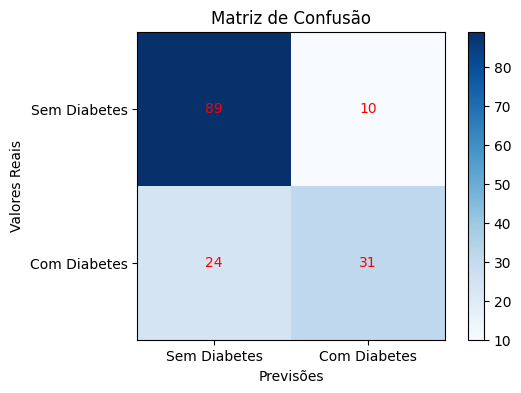

In [50]:
# Plota a matrix de confusão
plt.figure(figsize=(6, 4))
plt.imshow(confusion_matrix(y_teste, previsoes), cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.xticks([0, 1], ['Sem Diabetes', 'Com Diabetes'])
plt.yticks([0, 1], ['Sem Diabetes', 'Com Diabetes'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, confusion_matrix(y_teste, previsoes)[i, j], ha='center', va='center', color='red')
plt.colorbar()
plt.show()

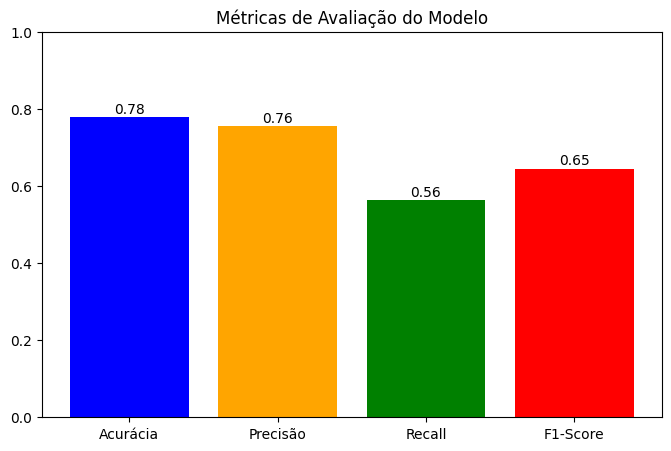

In [57]:
# Plota o gráfico de barra para mostrar a acurácia, precisão, recall e f1-score do modelo
plt.figure(figsize=(8, 5))
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores = [accuracy_score(y_teste, previsoes), precision_score(y_teste, previsoes), recall_score(y_teste, previsoes), f1_score(y_teste, previsoes)]
plt.bar(metricas, valores, color=['blue', 'orange', 'green', 'red'])
plt.title('Métricas de Avaliação do Modelo')
plt.ylim(0, 1)
for i, valor in enumerate(valores):
    plt.text(i, valor + 0.02, f'{valor:.2f}', ha='center', va='center')
plt.show()

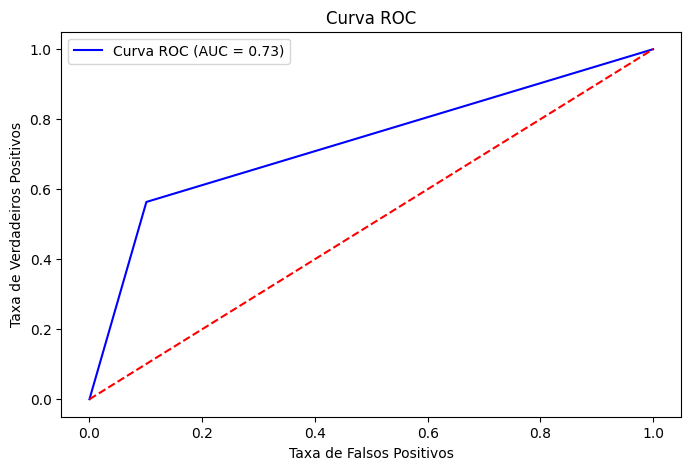

In [63]:
# Plota um gráfico com a curva ROC, para mostrar a taxa de verdadeiros positivos e falsos positivos
plt.figure(figsize=(8, 5))
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_teste, previsoes)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend()
plt.show()

Agora vou salvar o modelo.

In [64]:
# Salvando a rede neural
rede_neural.model_.save('classificador_diabetes_pratica.keras')

## Conclusão
O modelo de rede neural construído para prever se um paciente tem ou não diabetes teve um desempenho razoável, com uma acurácia de aproximadamente 0.779, mas só a acurácia não é o suficiente para avaliar o desempenho do modelo, então usei a matriz de confusão, calculei a precisão, recall e f1 score para ter uma ideia melhor do desempenho do modelo, também usei a curva ROC para medir a confiabilidade do modelo.  
Como observado no gráfico de métricas, a precisão do modelo é de aproximadamente 76%, ou seja, em cada 100 previsões feitas, o modelo acerta certa de 76 delas, o recall é de aproximadamente 56%, o modelo é capaz de identificar de forma correta cerca de 56% dos casos positivos, ou seja, pacientes com diabetes, o f1 score é de aproximadamente 65%, ele está indicando um equilibrio entre precisão e recall, ou seja, o modelo tem um bom desempenho tanto em identificar os casos positivos quanto em evitar falsos positivos.  
A curva ROC mostrou que o modelo tem uma boa capacidade de discriminação entre as classes, com uma área sob a curva (AUC) de aproximadamente 0.73, o que indica que o modelo tem uma boa capacidade de distinguir entre pacientes com e sem diabetes.